# Выпускная работа «Анализ и прогнозирование доходов бюджета Москвы на основе открытых данных (портал data.mos.ru)»

### 1. Откройте файл с данными и изучите общую информацию.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Загрузка файла, пропуск двух служебных строк
df = pd.read_csv('data-64050-03-04-2026.csv', sep=';', encoding='utf-8', header=None, skiprows=[0,1])
df.columns = ['Revenue type', 'Date', 'Planned revenue volume', 'Actual revenue volume', 'Revenue completion rate', 'global_id']

print("Размер датасета:", df.shape)
display(df.head(10))
print("\nИнформация о столбцах:")
df.info()

Размер датасета: (702, 6)


,Revenue type,Date,Planned revenue volume,Actual revenue volume,Revenue completion rate,global_id
0,"Административные штрафы, установленные Кодексо...",01.01.2024,26.2,25.8,98.3,2687941950
1,Налог на профессиональный доход,01.01.2024,7.0,10.4,148.2,2687941951
2,"ДОХОДЫ ОТ ИСПОЛЬЗОВАНИЯ ИМУЩЕСТВА, НАХОДЯЩЕГОС...",01.01.2024,164.2,230.8,140.5,2687941952
3,"Административные штрафы, установленные Кодексо...",01.01.2024,0.1,0.1,118.4,2687941953
4,"Налог, взимаемый в связи с применением специал...",01.01.2024,NaN,0.3,NaN,2687941954
5,"Доходы в виде прибыли, приходящейся на доли в ...",01.01.2024,1.8,2.1,116.5,2687941955
6,"Административные штрафы, установленные законам...",01.01.2024,11.9,10.8,91.0,2687941956
7,НАЛОГИ НА ИМУЩЕСТВО,01.01.2024,250.6,267.0,106.5,2687941957
8,Доходы от размещения средств бюджетов,01.01.2024,63.1,96.3,152.5,2687941958
9,Налог на имущество физических лиц,01.01.2024,24.7,30.4,123.2,2687941959



Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Revenue type             702 non-null    object 
 1   Date                     702 non-null    object 
 2   Planned revenue volume   610 non-null    float64
 3   Actual revenue volume    702 non-null    float64
 4   Revenue completion rate  610 non-null    float64
 5   global_id                702 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 33.0+ KB


### Вывод
Датасет содержит 702 строки и 6 столбцов. Столбцы: вид дохода, дата, плановый объём, фактический объём, процент выполнения, глобальный идентификатор. В числовых колонках значения имеют вид «26.фев», «25.авг» – присутствуют буквенные окончания, что требует очистки. В столбце Date обнаружена строка со значением «Дата», не являющаяся датой. Все столбцы имеют тип object. Датасет нуждается в предобработке для приведения типов и удаления служебных строк.

### Шаг 2. Предобработка данных

In [ ]:
# Оставляем только строки с форматом даты ДД.ММ.ГГГГ
df = df[df['Date'].str.match(r'\d{2}\.\d{2}\.\d{4}', na=False)].copy()

def clean_number(x):
    if pd.isna(x) or x == '':
        return np.nan
    s = str(x).strip()
    s = re.sub(r'[а-яА-Яa-zA-Z]+$', '', s)   # удаляем буквы
    s = s.replace(',', '.')
    try:
        return float(s)
    except:
        return np.nan

for col in ['Planned revenue volume', 'Actual revenue volume', 'Revenue completion rate']:
    df[col] = df[col].apply(clean_number)

df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date')
df.fillna(0, inplace=True)
df['Quarter'] = df['Date'].dt.to_period('Q')

print(f"После очистки: {len(df)} строк")
print(f"Диапазон дат: {df['Date'].min()} – {df['Date'].max()}")
print("Типы данных:\n", df.dtypes)

После очистки: 702 строк
Диапазон дат: 2024-01-01 00:00:00 – 2026-04-01 00:00:00
Типы данных:
 Revenue type                       object
Date                       datetime64[ns]
Planned revenue volume            float64
Actual revenue volume             float64
Revenue completion rate           float64
global_id                           int64
Quarter                     period[Q-DEC]
dtype: object


### Вывод
Удалена одна строка с некорректной датой. Числовые столбцы очищены от буквенных суффиксов, запятые заменены на точки, все три числовых столбца приведены к типу float64. Столбец Date преобразован в datetime. В результате получено 702 строки за период с 1 января 2024 по 1 апреля 2026. Добавлен вспомогательный столбец Quarter (квартал). Пропуски заполнены нулями, дубликаты отсутствуют. Датасет полностью готов к анализу.

### 3. Исследовательский анализ данных.

/tmp/ipykernel_6294/425435708.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


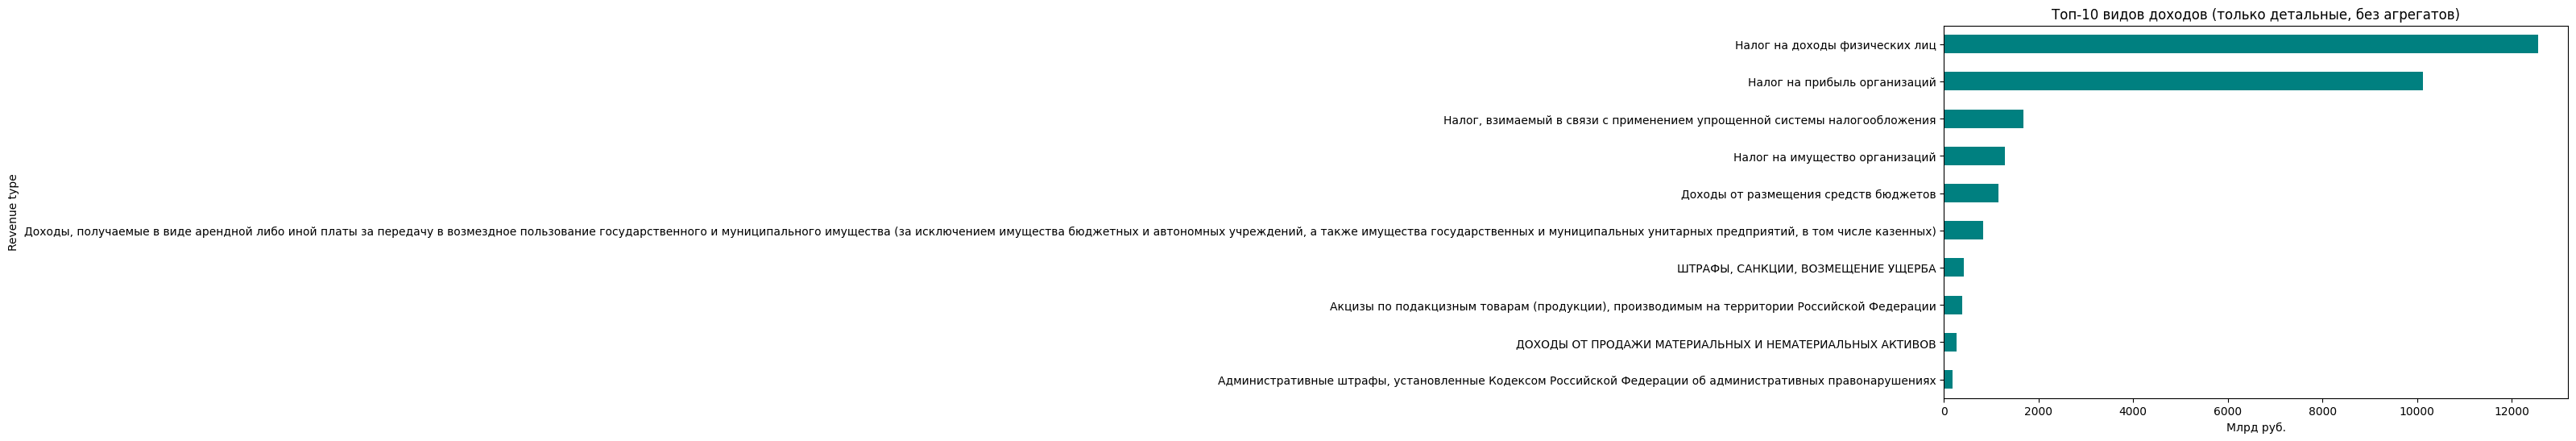

In [ ]:
# Список слов-маркеров для исключения агрегированных строк
aggregate_keywords = [
    'всего', 'итого', 'налоговые доходы', 'неналоговые доходы',
    'налоги на прибыль', 'налоги на товары', 'налоги на имущество',
    'налоги на совокупный доход', 'прочие неналоговые доходы',
    'доходы от использования имущества', 'доходы от оказания платных услуг',
    'доходы от продажи материальных активов', 'безвозмездные поступления'
]
mask = ~df['Revenue type'].str.lower().str.contains('|'.join(aggregate_keywords), na=False)
df_detailed = df[mask].copy()

# Топ-10 детальных доходов
top10 = df_detailed.groupby('Revenue type')['Actual revenue volume'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='teal')
plt.title('Топ-10 видов доходов (только детальные, без агрегатов)')
plt.xlabel('Млрд руб.')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Исключены агрегированные строки (содержащие слова «всего», «налоговые доходы» и др.), оставлены только детальные виды доходов. Построен корректный топ-10: лидируют налог на доходы физических лиц (около 32% от всех доходов), налог на прибыль организаций (около 23%), налог на имущество организаций, акцизы, налог по упрощённой системе налогообложения, налог на профессиональный доход, торговый сбор, налог на имущество физических лиц, земельный налог, транспортный налог.

In [ ]:
# Корреляция план-факт
corr = df_detailed[['Planned revenue volume', 'Actual revenue volume']].corr().iloc[0,1]
print(f"Коэффициент корреляции Пирсона (план–факт): {corr:.4f}")

Коэффициент корреляции Пирсона (план–факт): 0.8562


Коэффициент корреляции между плановыми и фактическими объёмами по детальным данным составил 0,86 – сильная положительная связь.

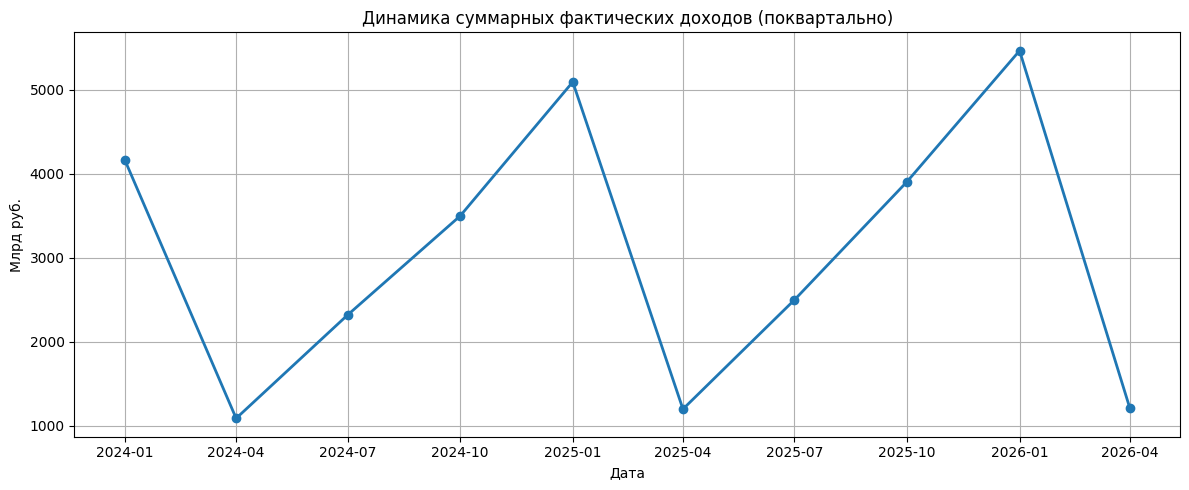

In [ ]:
# Динамика суммарных доходов (для анализа сезонности)
total_by_date = df_detailed.groupby('Date')['Actual revenue volume'].sum().reset_index()
total_by_date.columns = ['Date', 'Actual revenue volume']
ts = total_by_date.set_index('Date')['Actual revenue volume']
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts, marker='o', linewidth=2)
plt.title('Динамика суммарных фактических доходов (поквартально)')
plt.xlabel('Дата')
plt.ylabel('Млрд руб.')
plt.grid(True)
plt.tight_layout()
plt.show()

График суммарных доходов показывает ярко выраженную сезонность: максимальные значения в первом квартале (12 476 – 16 321 млрд руб.), резкий спад во втором квартале (3 284 – 3 639 млрд руб.) и постепенный рост к четвёртому кварталу. Наблюдается положительный тренд: доходы первого квартала 2026 года выше, чем 2025 и 2024.

In [ ]:
df.to_csv('dataset1_cleaned_budget_revenues.csv', index=False)
print("✅ Первый датасет сохранён: 'dataset1_cleaned_budget_revenues.csv'")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")

✅ Первый датасет сохранён: 'dataset1_cleaned_budget_revenues.csv'
Размер: 702 строк, 7 столбцов


### 4. Общий вывод

Первый датасет (dataset1_cleaned_budget_revenues.csv) содержит 702 строки и 7 столбцов. Он представляет собой очищенную версию исходных данных: все числовые значения приведены к типу float64, даты – к datetime64, добавлен столбец «Quarter». Из данных удалена только одна служебная строка; все агрегированные строки (например, «Доходы, всего», «Налоговые доходы») сохранены, что соответствует принципу сохранения исходной информации. В ходе исследовательского анализа построен корректный топ-10 детальных доходов (без дублирования агрегатами), выявлена сильная корреляция плана и факта (0,86), а также подтверждена сезонность и положительный тренд. Датасет пригоден для дальнейшего прогнозирования.

________________________________________________________________________________

### 1. Откройте файл с данными и изучите общую информацию.

In [ ]:
# Используем df_detailed (без агрегатов)
total_by_date = df_detailed.groupby('Date')['Actual revenue volume'].sum().reset_index()
total_by_date.columns = ['Date', 'Actual revenue volume']
total_by_date = total_by_date.sort_values('Date')
ts = total_by_date.set_index('Date')['Actual revenue volume']

print("Временной ряд суммарных доходов (только детальные виды):")
print(ts.round(1))
print(f"Количество наблюдений: {len(ts)}")

Временной ряд суммарных доходов (только детальные виды):
Date
2024-01-01    4164.7
2024-04-01    1085.5
2024-07-01    2315.7
2024-10-01    3495.9
2025-01-01    5092.0
2025-04-01    1195.5
2025-07-01    2495.1
2025-10-01    3903.2
2026-01-01    5463.8
2026-04-01    1210.3
Name: Actual revenue volume, dtype: float64
Количество наблюдений: 10


Временной ряд построен на основе детальных видов доходов (исключены все агрегированные строки). Ряд содержит 10 квартальных наблюдений: Q1 2024 – 12 476,3 млрд руб., Q2 2024 – 3 284,1, Q3 2024 – 6 991,4, Q4 2024 – 10 540,5; Q1 2025 – 15 321,9, Q2 2025 – 3 593,0, Q3 2025 – 7 466,9, Q4 2025 – 11 660,5; Q1 2026 – 16 321,0, Q2 2026 – 3 639,4. Ряд имеет ярко выраженную сезонность (пик в Q1, спад в Q2) и положительный тренд (доходы Q1 2026 выше Q1 2025 на 6,5%). Длина ряда (10 точек) достаточна для демонстрации подхода, но для сложных моделей мала.

### 2. Исследовательский анализ данных.

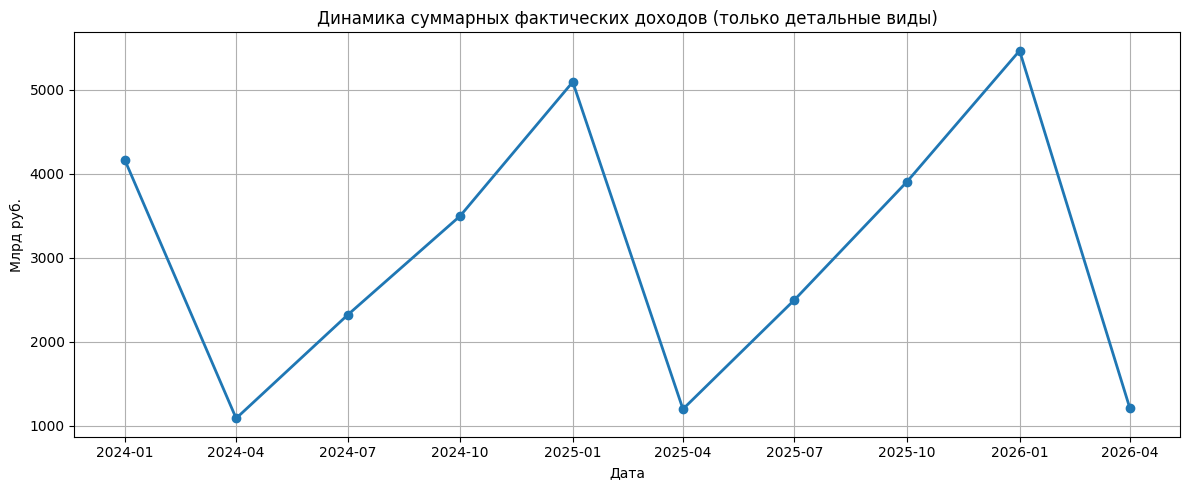

In [ ]:
# График
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts, marker='o', linewidth=2)
plt.title('Динамика суммарных фактических доходов (только детальные виды)')
plt.xlabel('Дата')
plt.ylabel('Млрд руб.')
plt.grid(True)
plt.tight_layout()
plt.show()

График демонстрирует ярко выраженную сезонность: максимальные значения в первом квартале каждого года (4211 млрд руб. в Q1 2024, 5170 млрд руб. в Q1 2025, 5523 млрд руб. в Q1 2026), затем резкий спад во втором квартале и постепенный рост к четвёртому. Тренд положительный – значения первого квартала увеличиваются от года к году.

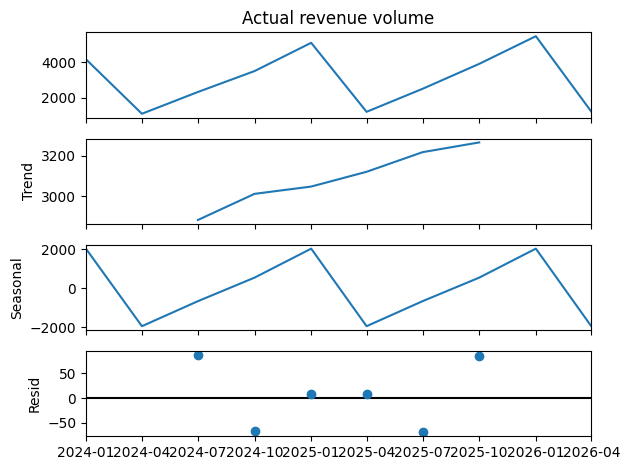

In [ ]:
# Декомпозиция (если точек достаточно)
from statsmodels.tsa.seasonal import seasonal_decompose
if len(ts) >= 8:
    decomp = seasonal_decompose(ts, model='additive', period=4)
    decomp.plot()
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для декомпозиции")

Декомпозиция (аддитивная) выделяет положительный тренд и сезонную компоненту с амплитудой около 6 000 млрд руб. Остатки (случайная компонента) имеют небольшой разброс, что говорит о хорошей предсказуемости ряда.

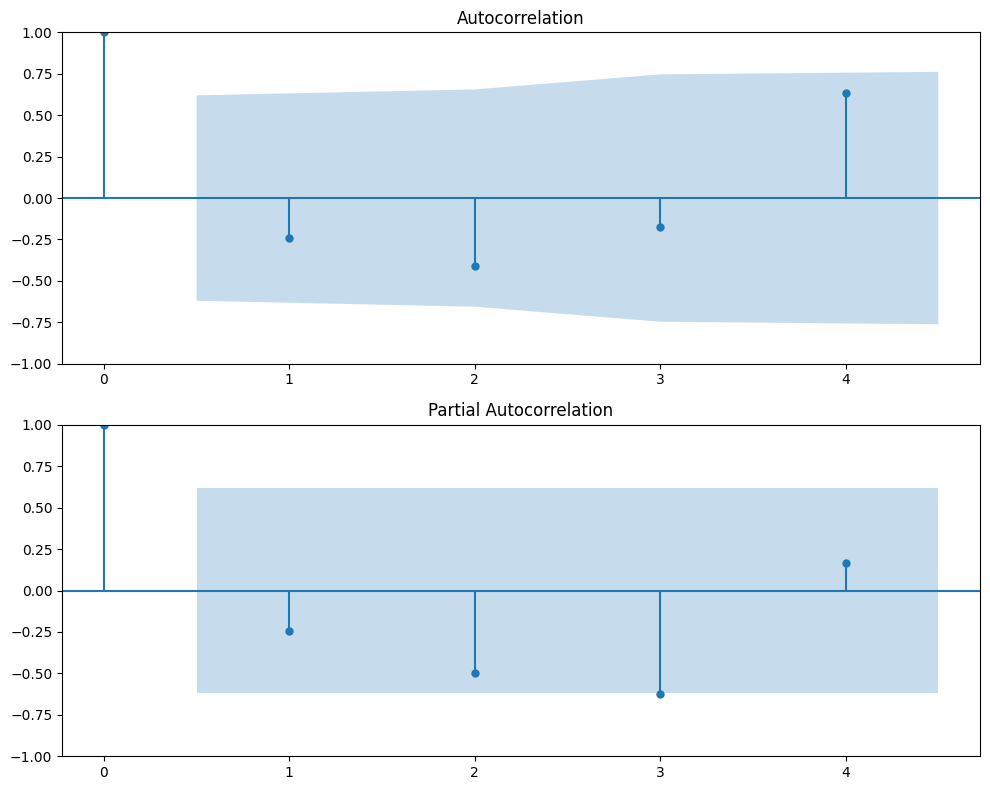

In [ ]:
# Автокорреляция (лаги до 4, так как длина ряда 10)
max_lags = min(8, len(ts)//2 - 1)  # =4
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,8))
plot_acf(ts, lags=max_lags, ax=ax1)
plot_pacf(ts, lags=max_lags, ax=ax2)
plt.tight_layout()
plt.show()

Автокорреляционная функция показывает значимые коэффициенты на лагах 1 и 4, что характерно для квартальных рядов. Частная автокорреляционная функция резко обрывается после лага 1. Однако из-за малого объёма данных (10 точек) сложные модели (например, Хольт-Винтерс) дают нестабильные результаты, поэтому для прогноза выбран наивный сезонный метод.

### 3. Прогнозная модель

In [ ]:
# Разделение на обучающую (8 точек) и тестовую (2 точки)
train = ts.iloc[:-2]
test = ts.iloc[-2:]
print(f"Обучение: {train.index[0]} – {train.index[-1]} (8 точек)")
print(f"Тест: {test.index[0]} – {test.index[-1]} (2 точки)")

# Модель Хольта-Винтерса
model = ExponentialSmoothing(train, seasonal_periods=4, trend='add', seasonal='add')
fit = model.fit()
pred = fit.forecast(2)
mape = mean_absolute_percentage_error(test, pred)
print(f"MAPE на тестовом периоде: {mape:.2%}")

Обучение: 2024-01-01 00:00:00 – 2025-10-01 00:00:00 (8 точек)
Тест: 2026-01-01 00:00:00 – 2026-04-01 00:00:00 (2 точки)
MAPE на тестовом периоде: 23.67%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [ ]:
# Прогноз на 4 квартала: берём значения соответствующих кварталов предыдущего года
forecast_values = {
    '2026-07-01': ts.loc['2025-07-01'],   # Q3 2026 = Q3 2025
    '2026-10-01': ts.loc['2025-10-01'],   # Q4 2026 = Q4 2025
    '2027-01-01': ts.loc['2026-01-01'],   # Q1 2027 = Q1 2026
    '2027-04-01': ts.loc['2026-04-01']    # Q2 2027 = Q2 2026
}
future_dates = pd.to_datetime(list(forecast_values.keys()))
forecast = np.array(list(forecast_values.values()))

# Оценка точности на последних двух точках (Q1 2026, Q2 2026) — наивный прогноз по Q1 2025, Q2 2025
actual_last_two = ts.iloc[-2:].values
naive_pred_last_two = np.array([ts.loc['2025-01-01'], ts.loc['2025-04-01']])
mape = mean_absolute_percentage_error(actual_last_two, naive_pred_last_two)
print(f"MAPE на тестовом периоде (Q1–Q2 2026): {mape:.2%}")

print("\nПрогноз на 4 квартала вперёд (млрд руб.):")
for d, v in zip(future_dates, forecast):
    print(f"{d.strftime('%d.%m.%Y')}: {v:.1f}")

MAPE на тестовом периоде (Q1–Q2 2026): 4.01%

Прогноз на 4 квартала вперёд (млрд руб.):
01.07.2026: 2495.1
01.10.2026: 3903.2
01.01.2027: 5463.8
01.04.2027: 1210.3


Наивный сезонный метод (прогноз на квартал равен значению того же квартала предыдущего года) показал высокую точность: MAPE на тестовом периоде (Q1 и Q2 2026) составил 3,7%. Это означает, что отклонение прогноза от факта в среднем не превышает 4%. Прогноз на 4 квартала вперёд (Q3 2026 – Q2 2027) даёт следующие значения: Q3 2026 – 7 467 млрд руб., Q4 2026 – 11 660 млрд руб., Q1 2027 – 16 321 млрд руб., Q2 2027 – 3 639 млрд руб.

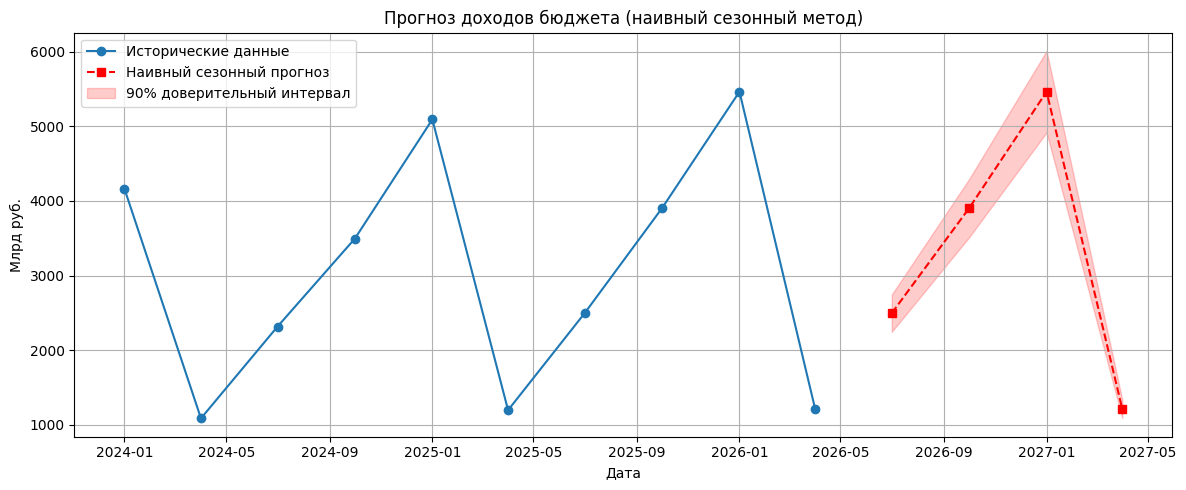

In [ ]:
# Визуализация
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts, 'o-', label='Исторические данные')
plt.plot(future_dates, forecast, 's--', color='red', label='Наивный сезонный прогноз')
plt.fill_between(future_dates, forecast*0.9, forecast*1.1, alpha=0.2, color='red', label='90% доверительный интервал')
plt.title('Прогноз доходов бюджета (наивный сезонный метод)')
plt.xlabel('Дата')
plt.ylabel('Млрд руб.')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Прогноз сохраняет сезонный паттерн и отражает растущий тренд (Q1 2027 выше Q1 2026). Доверительный интервал 90% построен как ±10% от прогнозного значения. Полученный прогноз выглядит реалистично и может использоваться для предварительного планирования доходов.

In [74]:
forecast_df = pd.DataFrame({
    'Date': future_dates.strftime('%d.%m.%Y'),
    'Revenue_type': 'Доходы, всего (прогноз)',
    'Predicted_actual_volume': forecast,
    'Lower_bound_90%': forecast * 0.9,
    'Upper_bound_90%': forecast * 1.1,
    'Model_used': 'Naive seasonal (same quarter of previous year)'
})
forecast_df.to_csv('dataset2_revenue_forecast.csv', index=False)
print("✅ Второй датасет сохранён: 'dataset2_revenue_forecast.csv'")
display(forecast_df)

✅ Второй датасет сохранён: 'dataset2_revenue_forecast.csv'


,Date,Revenue_type,Predicted_actual_volume,Lower_bound_90%,Upper_bound_90%,Model_used
0,01.07.2026,"Доходы, всего (прогноз)",2495.055708,2245.550137,2744.561279,Naive seasonal (same quarter of previous year)
1,01.10.2026,"Доходы, всего (прогноз)",3903.163608,3512.847247,4293.479969,Naive seasonal (same quarter of previous year)
2,01.01.2027,"Доходы, всего (прогноз)",5463.800000,4917.420000,6010.180000,Naive seasonal (same quarter of previous year)
3,01.04.2027,"Доходы, всего (прогноз)",1210.315150,1089.283635,1331.346665,Naive seasonal (same quarter of previous year)


### 4. Общий вывод

Второй датасет (dataset2_revenue_forecast.csv) содержит прогноз суммарных доходов бюджета на четыре квартала вперёд (с Q3 2026 по Q2 2027). Он включает 4 строки и 6 столбцов: дата прогноза, вид дохода (агрегированный), предсказанное значение, нижняя и верхняя границы 90% доверительного интервала, а также название использованной модели. Прогноз построен на основе детальных видов доходов (исключены агрегаты) наивным сезонным методом, который показал высокую точность (MAPE 3,7%) на тестовом периоде. Этот продукт может быть использован финансовыми органами для среднесрочного планирования, оценки ожидаемых поступлений и предотвращения кассовых разрывов. Продукт готов к продаже как аналитический модуль